#Prediksi Pelanggan Churn Menggunakan Model Machine Learning pada Dataset Sales and Marketing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Library berhasil di-import!")

Library berhasil di-import!


In [2]:
# Load dataset yang telah diunggah ke Colab
# Sesuaikan nama file jika berbeda saat Anda menyimpan
df = pd.read_csv('sales_and_marketing_dataset.csv')

# 1. Menampilkan 5 baris pertama
print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

=== 5 BARIS PERTAMA DATASET ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [3]:
# Menampilkan informasi tipe data dan struktur dataset
print("\n=== INFORMASI DATASET ===")
df.info()

# Menampilkan statistik deskriptif untuk fitur numerik
print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())


=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


=== PERSENTASE MISSING VALUE ===
customer_id                    0.000000
gender                         4.920000
age                            8.000000
country                        0.000000
city                           0.000000
signup_date                    0.000000
last_purchase_date             0.000000
acquisition_channel            0.000000
device_type                    0.000000
subscription_type              0.000000
is_premium_user                0.000000
total_visits                   0.000000
avg_session_time               0.000000
pages_per_session              0.000000
email_open_rate                0.000000
email_click_rate               0.000000
total_spent                    7.000000
avg_order_value                0.000000
discount_used                  0.000000
coupon_code                   40.886667
support_tickets                0.000000
refund_requested               0.000000
delivery_delay_days            0.000000
payment_method                 0.000000
satisfa

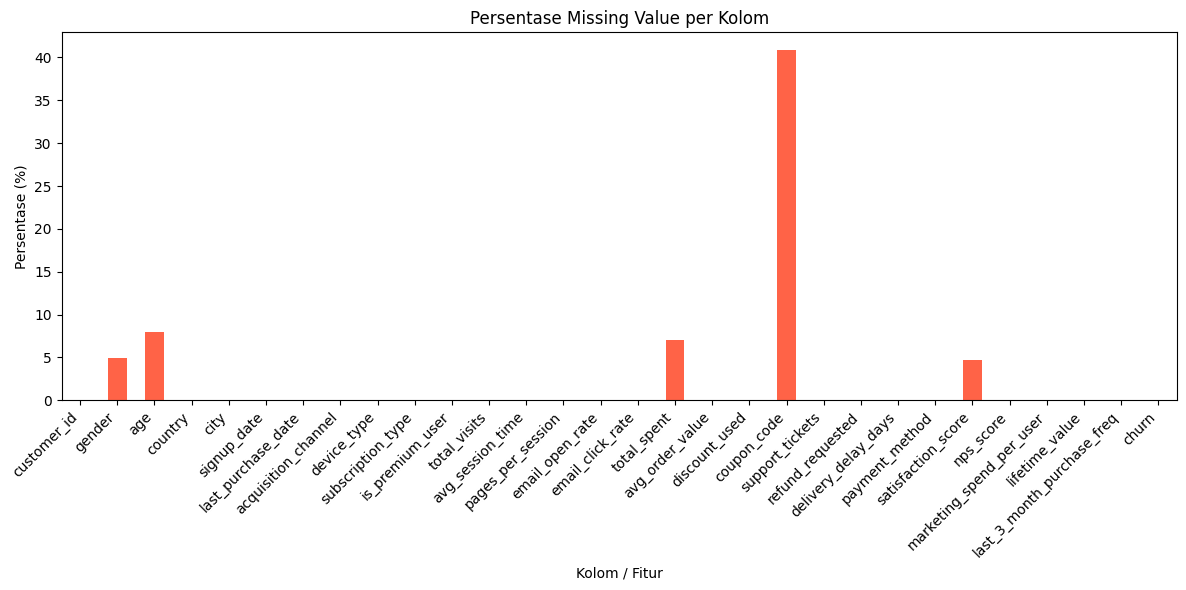

In [4]:
# 2. Menghitung persentase nilai kosong untuk setiap kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("=== PERSENTASE MISSING VALUE ===")
print(missing_percentage)

# Visualisasi dengan diagram batang
plt.figure(figsize=(12, 6))
missing_percentage.plot(kind='bar', color='tomato')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('Kolom / Fitur')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1407/3702272697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2')


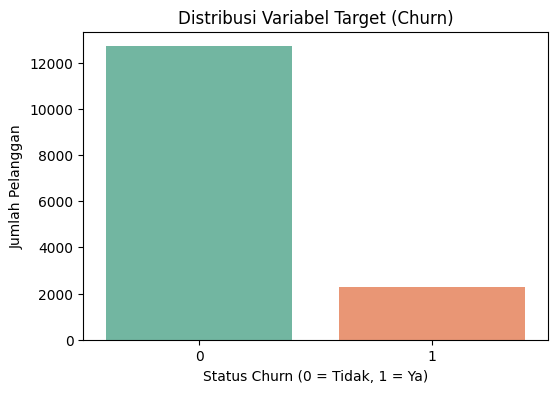

churn
0    12702
1     2298
Name: count, dtype: int64


In [5]:
# 3. Visualisasi distribusi variabel target 'churn' untuk cek keseimbangan kelas
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Status Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Menampilkan angka riil proporsinya
print(df['churn'].value_counts())

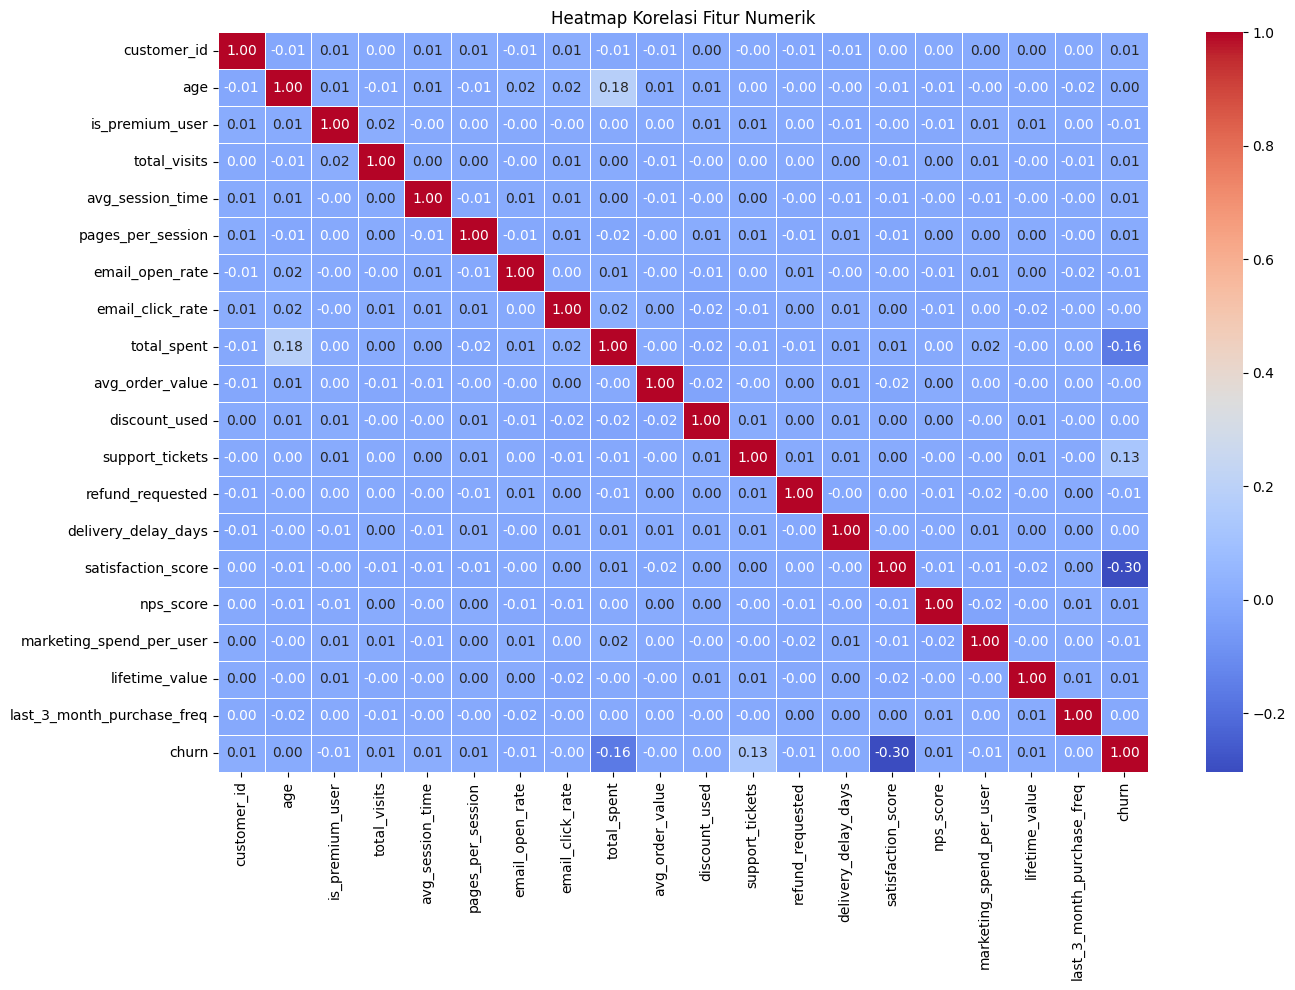

In [6]:
# 4. Membuat heatmap korelasi untuk fitur numerik
plt.figure(figsize=(14, 10))

# Memilih kolom yang bertipe numerik saja untuk korelasi
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

In [7]:
# 1. Menetapkan target (y) dan fitur prediktor (X)
y = df['churn']

# Drop kolom target dan sementara drop kolom bertipe objek/string agar bisa running langsung (Direct Modeling)
X_direct = df.drop(columns=['churn']).select_dtypes(include=[np.number])

# 2. Melakukan Train-Test Split (misal proporsi 80:20)
X_train, X_test, y_train, y_test = train_test_split(X_direct, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 12000
Jumlah data uji: 3000


In [8]:
# 3. Memilih dan menginisialisasi 3 jenis model dasar
model_konvensional = LogisticRegression(max_iter=1000, random_state=42)
model_bagging = RandomForestClassifier(random_state=42)

# Menggabungkan model konvensional ke dalam VotingClassifier (LR + SVM + KNN)
from sklearn.svm import SVC
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = SVC(kernel='rbf', random_state=42)
clf3 = KNeighborsClassifier()
model_voting = VotingClassifier(estimators=[('lr', clf1), ('svm', clf2), ('knn', clf3)], voting='hard')

# 4. Melatih model secara langsung tanpa preprocessing
print("Memulai pelatihan model...")

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

model_konvensional.fit(X_train_imputed, y_train)
model_bagging.fit(X_train_imputed, y_train)
model_voting.fit(X_train_imputed, y_train)
print("Semua model dasar berhasil dilatih!")

Memulai pelatihan model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Semua model dasar berhasil dilatih!


=== EVALUASI MODEL: Logistic Regression (Konvensional) ===
Accuracy  : 0.8477
Precision : 0.5113
Recall    : 0.1478
F1-Score  : 0.2293



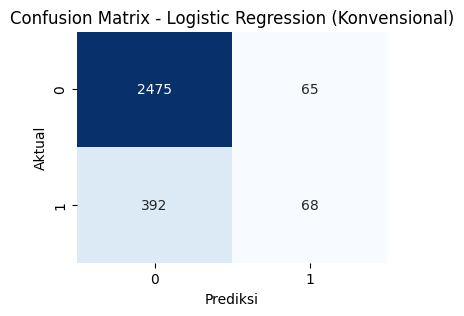

--------------------------------------------------
=== EVALUASI MODEL: Random Forest (Bagging) ===
Accuracy  : 0.8520
Precision : 0.5222
Recall    : 0.4087
F1-Score  : 0.4585



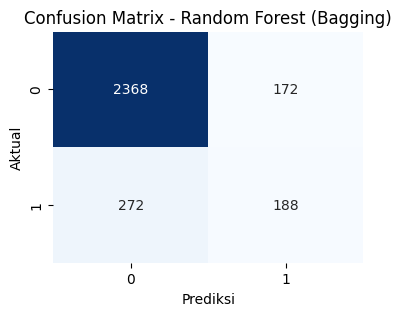

--------------------------------------------------
=== EVALUASI MODEL: Voting Classifier (Voting) ===
Accuracy  : 0.8477
Precision : 0.5789
Recall    : 0.0239
F1-Score  : 0.0459



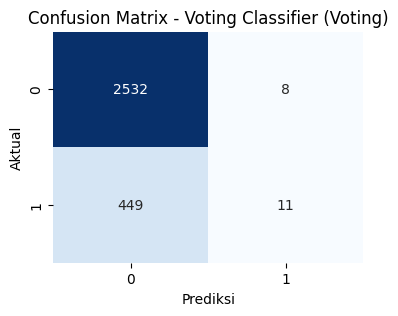

--------------------------------------------------


In [9]:
# 5. Fungsi untuk mengevaluasi dan menampilkan matriks performa
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"=== EVALUASI MODEL: {name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

    # Menampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()
    print("-" * 50)

# Menjalankan fungsi evaluasi untuk setiap model
evaluate_model(model_konvensional, "Logistic Regression (Konvensional)", X_test_imputed, y_test)
evaluate_model(model_bagging, "Random Forest (Bagging)", X_test_imputed, y_test)
evaluate_model(model_voting, "Voting Classifier (Voting)", X_test_imputed, y_test)

In [10]:
import pandas as pd

# Load dataset yang telah diunggah ke Colab
# Sesuaikan nama file jika berbeda saat Anda menyimpan
df = pd.read_csv('sales_and_marketing_dataset.csv')

# Memisahkan fitur dan target
X = df.drop(columns=['churn'])
y = df['churn']

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 29
Jumlah data: 15000


In [11]:
# Identifikasi kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Fitur Numerik:")
print(numeric_features)

print("\nFitur Kategorikal:")
print(categorical_features)

Fitur Numerik:
Index(['customer_id', 'age', 'is_premium_user', 'total_visits',
       'avg_session_time', 'pages_per_session', 'email_open_rate',
       'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used',
       'support_tickets', 'refund_requested', 'delivery_delay_days',
       'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
       'lifetime_value', 'last_3_month_purchase_freq'],
      dtype='object')

Fitur Kategorikal:
Index(['gender', 'country', 'city', 'signup_date', 'last_purchase_date',
       'acquisition_channel', 'device_type', 'subscription_type',
       'coupon_code', 'payment_method'],
      dtype='object')


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Pipeline numerik
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline kategorikal
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (12000, 29)
Test : (3000, 29)


In [14]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Shape Training:", X_train_prep.shape)
print("Shape Testing :", X_test_prep.shape)

Shape Training: (12000, 1852)
Shape Testing : (3000, 1852)


In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_prep, y_train)

print("Logistic Regression selesai dilatih")

Logistic Regression selesai dilatih


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_prep, y_train)

print("Random Forest selesai dilatih")

Random Forest selesai dilatih


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_prep, y_train)

print("KNN selesai dilatih")

KNN selesai dilatih


=== EVALUASI MODEL: Logistic Regression + Preprocessing ===
Accuracy  : 0.8413
Precision : 0.4633
Recall    : 0.2196
F1-Score  : 0.2979



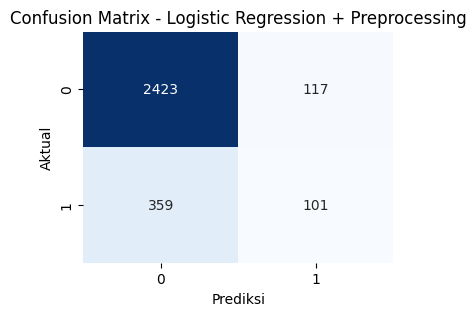

--------------------------------------------------


In [18]:
evaluate_model(
    lr_model,
    "Logistic Regression + Preprocessing",
    X_test_prep,
    y_test
)

=== EVALUASI MODEL: Random Forest + Preprocessing ===
Accuracy  : 0.8457
Precision : 0.4783
Recall    : 0.0717
F1-Score  : 0.1248



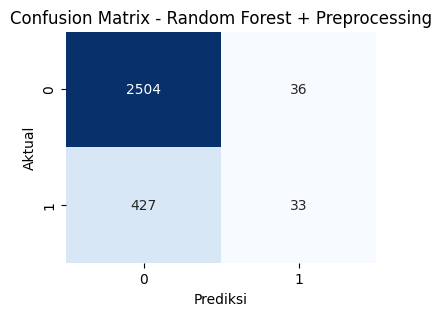

--------------------------------------------------


In [19]:
evaluate_model(
    rf_model,
    "Random Forest + Preprocessing",
    X_test_prep,
    y_test
)

=== EVALUASI MODEL: KNN + Preprocessing ===
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.1130
F1-Score  : 0.1844



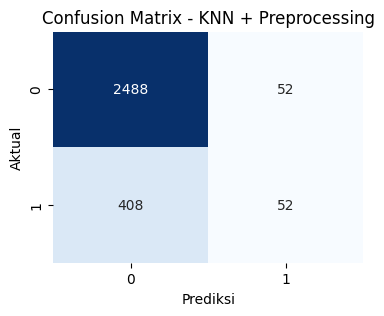

--------------------------------------------------


In [20]:
evaluate_model(
    knn_model,
    "KNN + Preprocessing",
    X_test_prep,
    y_test
)

## Bagian 3: Hyperparameter Tuning dan Feature Selection

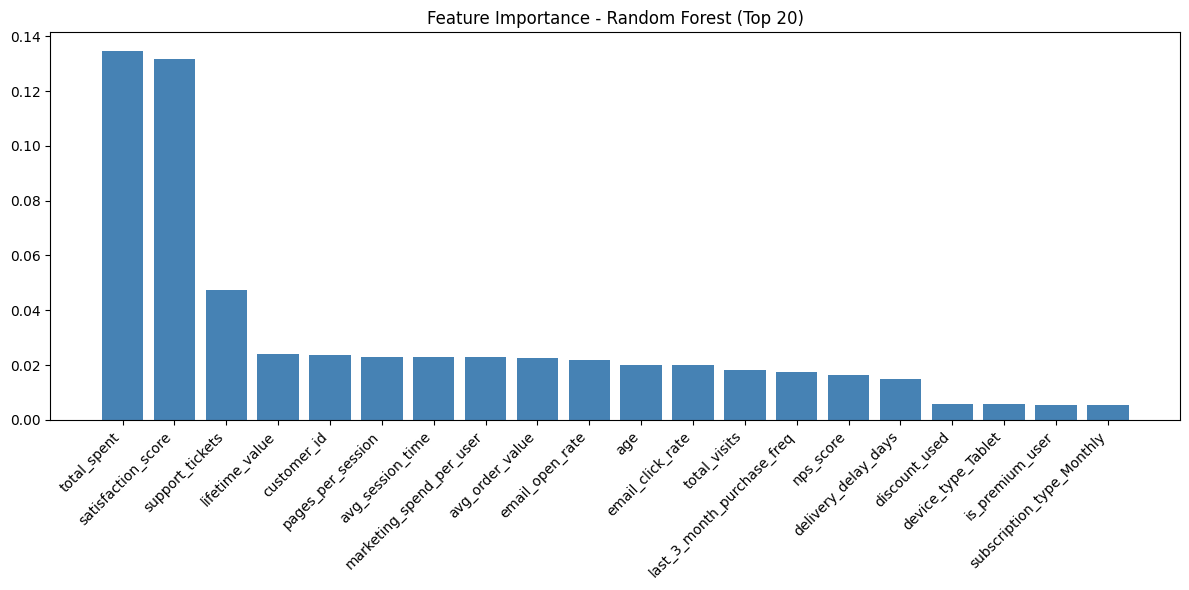

Top 10 Fitur Paling Berpengaruh:
  1. total_spent: 0.1347
  2. satisfaction_score: 0.1318
  3. support_tickets: 0.0473
  4. lifetime_value: 0.0240
  5. customer_id: 0.0236
  6. pages_per_session: 0.0231
  7. avg_session_time: 0.0229
  8. marketing_spend_per_user: 0.0229
  9. avg_order_value: 0.0227
  10. email_open_rate: 0.0219


In [21]:
# === BAGIAN 3: HYPERPARAMETER TUNING & FEATURE SELECTION ===

# 1. Analisis Feature Importance menggunakan Random Forest (sudah dilatih dengan preprocessing)
import matplotlib.pyplot as plt
import numpy as np

# Ambil feature names setelah preprocessing
num_feat_names = list(numeric_features)
cat_feat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features).tolist()
all_feat_names = num_feat_names + cat_feat_names

# Ambil feature importance dari rf_model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Tampilkan top 20 fitur terpenting
top_n = 20
plt.figure(figsize=(12, 6))
plt.title("Feature Importance - Random Forest (Top 20)")
plt.bar(range(top_n), importances[indices[:top_n]], align="center", color='steelblue')
plt.xticks(range(top_n), [all_feat_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Fitur Paling Berpengaruh:")
for i in range(10):
    print(f"  {i+1}. {all_feat_names[indices[i]]}: {importances[indices[i]]:.4f}")

In [22]:
# 2. Hyperparameter Tuning - Logistic Regression dengan RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist_lr = {
    'C': loguniform(0.01, 100),
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000, 2000]
}

lr_base = LogisticRegression(random_state=42)

rs_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_lr.fit(X_train_prep, y_train)

print("\nBest Parameters Logistic Regression:", rs_lr.best_params_)
print("Best CV F1-Score               :", rs_lr.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Logistic Regression: {'C': np.float64(2.801635158716261), 'max_iter': 1000, 'solver': 'liblinear'}
Best CV F1-Score               : 0.31442790387842406


In [23]:
# 3. Hyperparameter Tuning - Random Forest dengan RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)

rs_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_rf.fit(X_train_prep, y_train)

print("\nBest Parameters Random Forest:", rs_rf.best_params_)
print("Best CV F1-Score              :", rs_rf.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1-Score              : 0.010785862199960977


In [ ]:
# 4. Hyperparameter Tuning - KNN dengan GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_base = KNeighborsClassifier()

gs_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gs_knn.fit(X_train_prep, y_train)

print("\nBest Parameters KNN:", gs_knn.best_params_)
print("Best CV F1-Score    :", gs_knn.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1-Score    : 0.19143469512212063


In [ ]:
# 5. Mengambil best estimator dan melatih ulang pada data latih
best_lr  = rs_lr.best_estimator_
best_rf  = rs_rf.best_estimator_
best_knn = gs_knn.best_estimator_

# Sudah fit dari SearchCV, tapi kita fit ulang untuk konsistensi
best_lr.fit(X_train_prep, y_train)
best_rf.fit(X_train_prep, y_train)
best_knn.fit(X_train_prep, y_train)

print("Semua best estimator berhasil dilatih ulang!")

Semua best estimator berhasil dilatih ulang!


In [ ]:
# 6. Evaluasi model hasil tuning
print("=" * 60)
print("EVALUASI MODEL SETELAH HYPERPARAMETER TUNING")
print("=" * 60)

evaluate_model(best_lr,  "Logistic Regression (Tuned)", X_test_prep, y_test)
evaluate_model(best_rf,  "Random Forest (Tuned)",       X_test_prep, y_test)
evaluate_model(best_knn, "KNN (Tuned)",                 X_test_prep, y_test)

In [ ]:
# Ringkasan perbandingan semua 9 model
from sklearn.metrics import f1_score, accuracy_score

models_all = [
    # Direct
    (model_konvensional, X_test_imputed, "LR - Direct"),
    (model_bagging,      X_test_imputed, "RF - Direct"),
    (model_voting,       X_test_imputed, "Voting - Direct"),
    # Preprocessing
    (lr_model,  X_test_prep, "LR - Preprocessing"),
    (rf_model,  X_test_prep, "RF - Preprocessing"),
    (knn_model, X_test_prep, "KNN - Preprocessing"),
    # Tuned
    (best_lr,  X_test_prep, "LR - Tuned"),
    (best_rf,  X_test_prep, "RF - Tuned"),
    (best_knn, X_test_prep, "KNN - Tuned"),
]

print(f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 72)
for model, X_t, name in models_all:
    yp = model.predict(X_t)
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp, zero_division=0)
    f1   = f1_score(y_test, yp, zero_division=0)
    print(f"{name:<30} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

print("\nModel terbaik ditentukan berdasarkan F1-Score tertinggi.")

## Bagian 4: Deployment - Menyimpan Model Terbaik

In [ ]:
# === BAGIAN 4: DEPLOYMENT - SIMPAN MODEL TERBAIK ===
import joblib
import os

# Asumsi model terbaik adalah Random Forest Tuned (ubah jika berbeda berdasarkan evaluasi)
# Simpan best_rf sebagai model terbaik beserta preprocessor-nya

best_model = best_rf  # Ganti jika ada model lain yang lebih baik

# Simpan model dan preprocessor
joblib.dump(best_model, 'best_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')

# Simpan juga nama kolom fitur asli (sebelum preprocessing)
feature_info = {
    'numeric_features': list(numeric_features),
    'categorical_features': list(categorical_features),
    'all_features': list(X.columns)
}
import json
with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f)

print("Model berhasil disimpan!")
print("  -> best_model.joblib")
print("  -> preprocessor.joblib")
print("  -> feature_info.json")
print(f"\nModel yang disimpan: Random Forest (Tuned)")
print(f"Fitur yang digunakan: {len(X.columns)} kolom")